In [ ]:
import sys
!{sys.executable} -m pip install xgboost

In [1]:
# 라이브러리 Import
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import xgboost as xgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("="*60)

라이브러리 로드 완료!


In [2]:
df1 = pd.read_csv('product_type_1.csv',header=[0,1])

In [3]:
df1

Process                                                     \
           id Product_Type Shot Velocity_1 Velocity_2 Velocity_3   
0           1            1    1      0.144      0.170      0.188   
1        1002            1    2      0.144      0.170      0.182   
2        2003            1    3      0.144      0.170      0.182   
3        3004            1    4      0.144      0.170      0.182   
4        4005            1    5      0.144      0.172      0.176   
...       ...          ...  ...        ...        ...        ...   
2648  4197741            1  741      0.168      0.210      0.220   
2649  4199742            1  742      0.168      0.212      0.234   
2650  4201743            1  743      0.166      0.210      0.222   
2651  4203744            1  744      0.174      0.210      0.227   
2652  4205745            1  745      0.176      0.206      0.230   

                                                                        \
     High_Velocity Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness   
0            2.134               214           0.008                10   
1            2.124               217           0.008                11   
2            2.116               214           0.008                11   
3            2.137               217           0.008                11   
4            2.111               217           0.008                12   
...            ...               ...             ...               ...   
2648         2.217               239           0.009                12   
2649         2.238               239           0.010                13   
2650         2.277               239           0.008                12   
2651         2.260               239           0.010                12   
2652         2.254               239           0.007                12   

                                                                               \
     Clamping_Force Cycle_Time Pressure_Rise_Time Casting_Pressure Spray_Time   
0               258       20.7              0.044             1037        7.8   
1               257       20.7              0.044             1052        7.8   
2               257       20.8              0.041             1037        7.8   
3               257       20.7              0.043             1051        7.8   
4               257       20.7              0.042             1052        7.8   
...             ...        ...                ...              ...        ...   
2648            257       21.0              0.044             1156        7.2   
2649            257       20.8              0.043             1156        7.1   
2650            255       20.7              0.044             1156        7.0   
2651            257       20.7              0.043             1157        7.1   
2652            257       20.8              0.043             1156        7.1   

                                             Sensor               \
     Spray_1_Time Spray_2_Time Melting_Furnace_Temp Air_Pressure   
0             0.7          0.8                695.0          6.3   
1             0.7          0.8                696.4          6.3   
2             0.7          0.8                696.4          6.3   
3             0.7          0.8                696.4          6.3   
4             0.7          0.8                697.9          6.4   
...           ...          ...                  ...          ...   
2648          1.2          0.7                680.4          6.8   
2649          1.0          0.7                679.1          7.0   
2650          1.0          0.7                679.1          7.0   
2651          1.0          0.7                679.1          7.0   
2652          1.0          0.7                678.0          6.8   

                                                                      \
     Air_Pressure_Min Air_Pressure_Max Coolant_Temp Coolant_Temp_Min   
0                   3                9         26.0               10   
1  

In [5]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 2653 entries, 0 to 2652
Data columns (total 58 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   (Process, id)                   2653 non-null   int64  
 1   (Process, Product_Type)         2653 non-null   int64  
 2   (Process, Shot)                 2653 non-null   int64  
 3   (Process, Velocity_1)           2653 non-null   float64
 4   (Process, Velocity_2)           2653 non-null   float64
 5   (Process, Velocity_3)           2653 non-null   float64
 6   (Process, High_Velocity)        2653 non-null   float64
 7   (Process, Cylinder_Pressure)    2653 non-null   int64  
 8   (Process, Rapid_Rise_Time)      2653 non-null   float64
 9   (Process, Biscuit_Thickness)    2653 non-null   int64  
 10  (Process, Clamping_Force)       2653 non-null   int64  
 11  (Process, Cycle_Time)           2653 non-null   float64
 12  (Process, Pressure_Rise_Time)   2653 non-null

In [7]:
# 2) 간단한 EDA
print("\n결측치:\n", df1.isnull().sum().sort_values(ascending=False).head(10)) 
print("\n타겟 비율:\n", df1[('Defect_Flag', 'Is_Defect')].value_counts(normalize=True))


결측치:
 Process  id                   0
         Product_Type         0
         Shot                 0
         Velocity_1           0
         Velocity_2           0
         Velocity_3           0
         High_Velocity        0
         Cylinder_Pressure    0
         Rapid_Rise_Time      0
         Biscuit_Thickness    0
dtype: int64

타겟 비율:
 (Defect_Flag, Is_Defect)
0    0.782887
1    0.217113
Name: proportion, dtype: float64


In [8]:
# y: 불량 여부(0/1)
y = df1[('Defect_Flag', 'Is_Defect')].astype(int)

# # y: Defects 그룹 전체 (멀티라벨)
# y_cols = [c for c in df.columns if c[0] == 'Defects']
# y = df[y_cols].astype(int)

X = df1[['Process','Sensor']].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
print("train:", X_train.shape)
print("test:", X_test.shape)

print("train 불량률:", y_train.mean())
print("test 불량률:", y_test.mean())

train: (2122, 31)
test: (531, 31)
train 불량률: 0.2172478793590952
test 불량률: 0.21657250470809794


In [10]:
X_train.isnull().sum()

Process  id                      0
         Product_Type            0
         Shot                    0
         Velocity_1              0
         Velocity_2              0
         Velocity_3              0
         High_Velocity           0
         Cylinder_Pressure       0
         Rapid_Rise_Time         0
         Biscuit_Thickness       0
         Clamping_Force          0
         Cycle_Time              0
         Pressure_Rise_Time      0
         Casting_Pressure        0
         Spray_Time              0
         Spray_1_Time            0
         Spray_2_Time            0
Sensor   Melting_Furnace_Temp    0
         Air_Pressure            0
         Air_Pressure_Min        0
         Air_Pressure_Max        0
         Coolant_Temp            0
         Coolant_Temp_Min        0
         Coolant_Temp_Max        0
         Coolant_Pressure        0
         Factory_Temp            0
         Factory_Temp_Min        0
         Factory_Temp_Max        0
         Factory_Hum

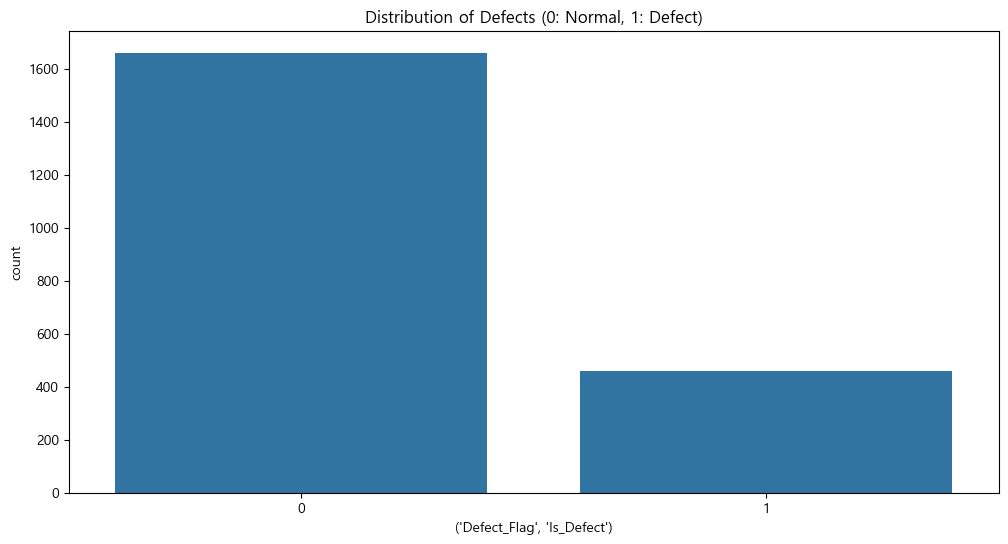

In [11]:
# y_train의 분포 확인
sns.countplot(x=y_train)
plt.title('Distribution of Defects (0: Normal, 1: Defect)')
plt.show()

In [15]:
y_train

528     1
1852    0
2635    0
2503    0
1419    0
       ..
261     1
898     0
1749    0
1895    0
1791    1
Name: (Defect_Flag, Is_Defect), Length: 2122, dtype: int64

In [16]:
# y_train을 1차원 array로 변환
target_values = y_train.values.flatten() 

train_df = X_train.copy()
train_df['Target'] = target_values

<Axes: xlabel='Target', ylabel="('Sensor', 'Melting_Furnace_Temp')">

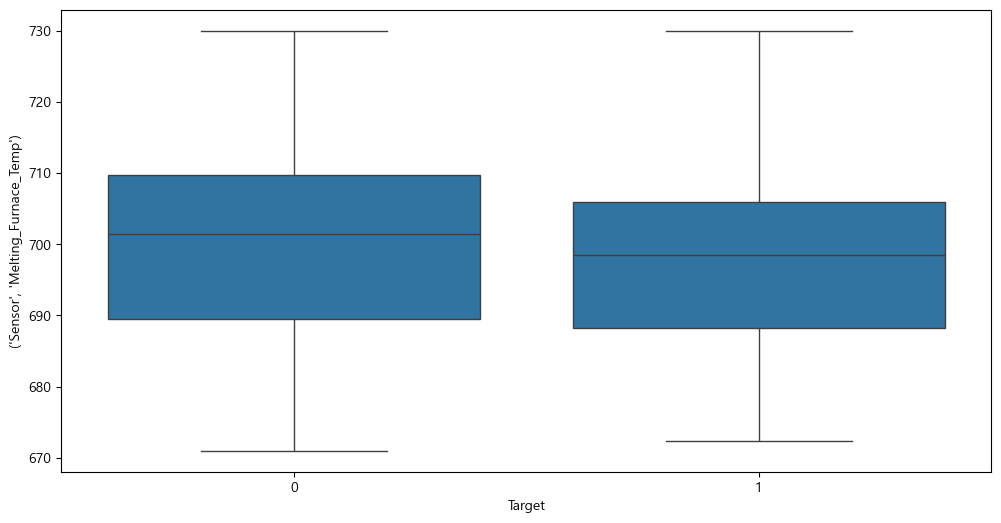

In [17]:
# 센서 컬럼들만 리스트로 뽑기
sensor_cols = [c for c in X_train.columns if 'Sensor' in str(c)]

# 첫 번째 센서에 대해서만 그려보기
import seaborn as sns
sns.boxplot(x='Target', y=sensor_cols[0], data=train_df)

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. y_train의 차원을 확실히 맞춤
target = y_train.values.ravel() 

# 2. 분석용 데이터프레임 생성
df_eda = X_train.copy()
df_eda['Target'] = target

print(df_eda.shape) # 여기서 (2122, 15) 내외로 나와야 정상입니다.

(2122, 32)


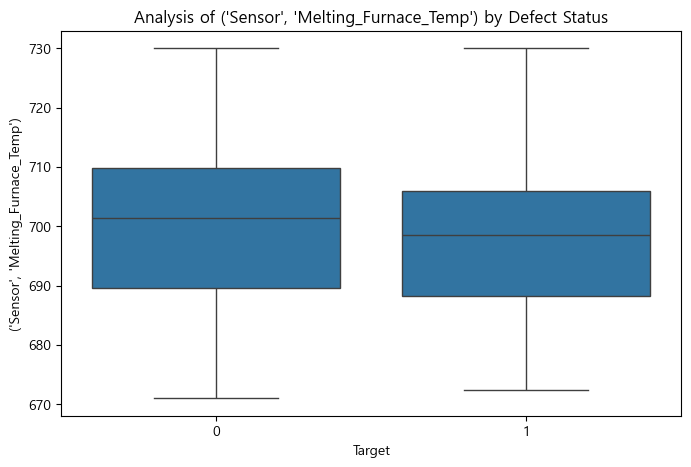

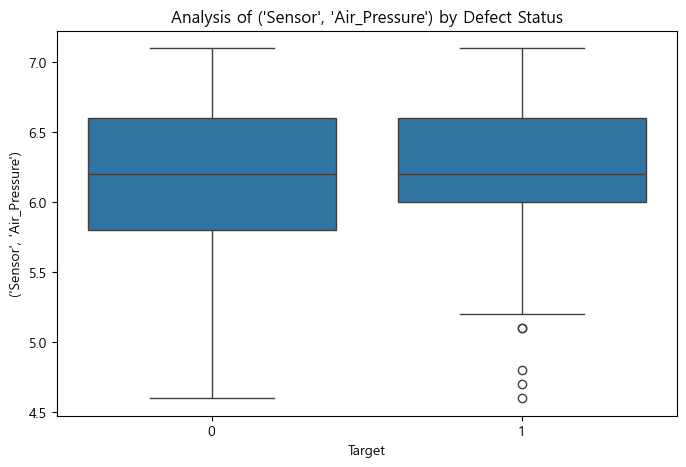

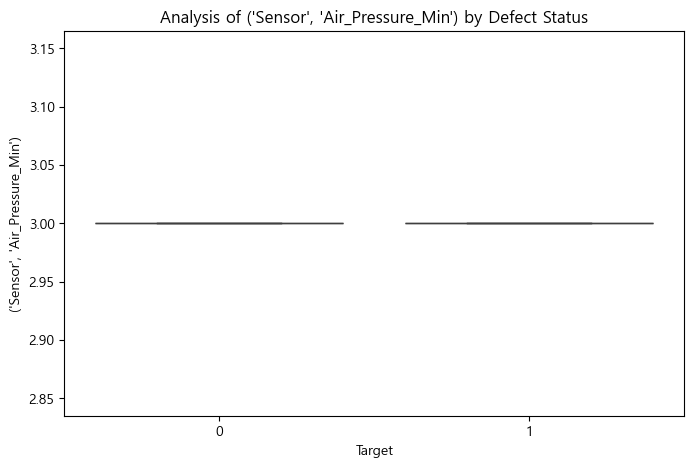

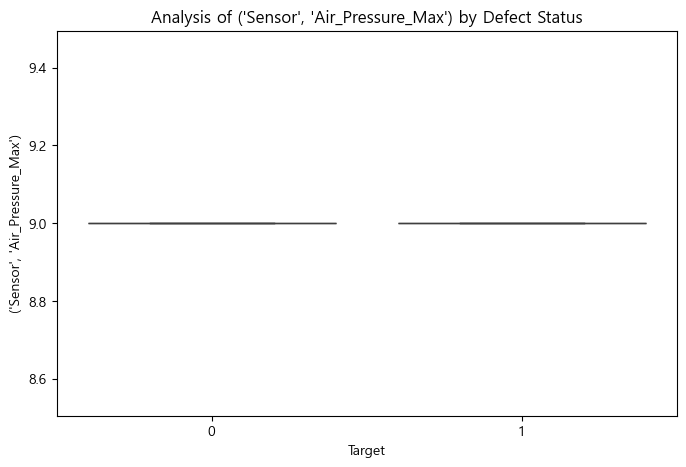

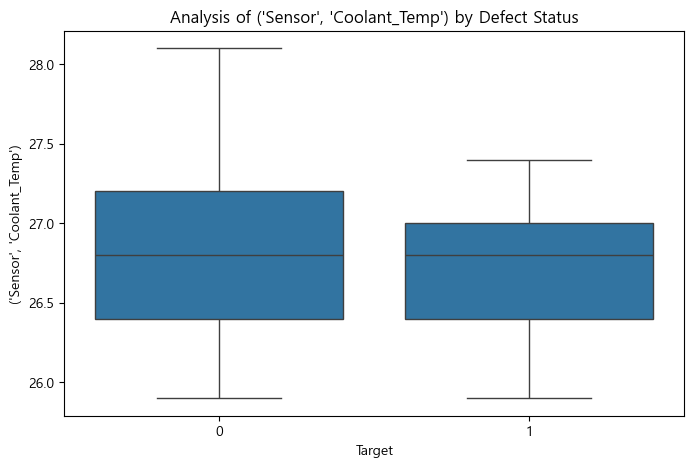

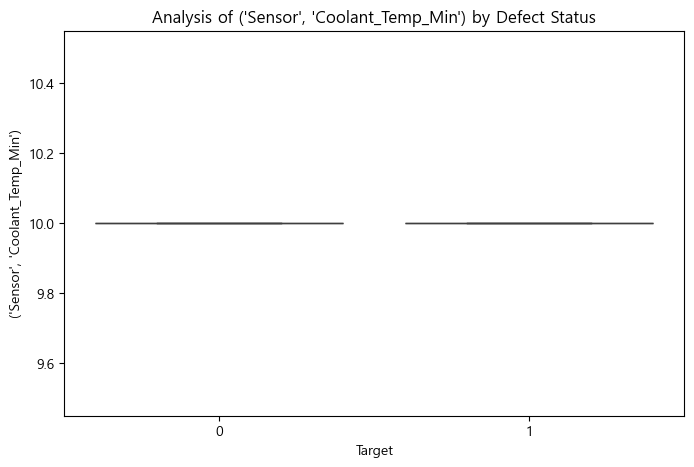

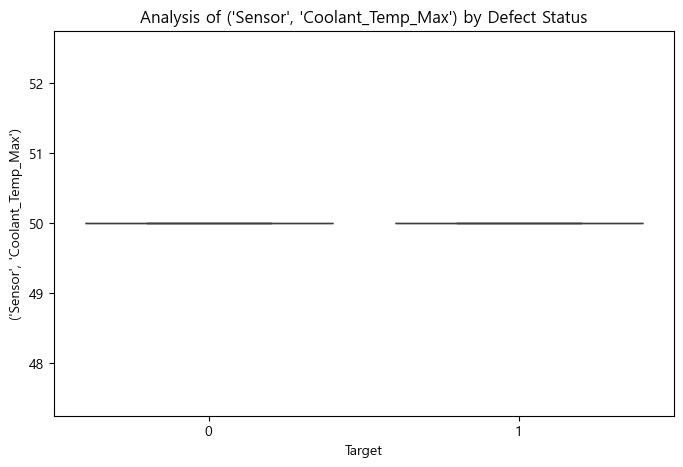

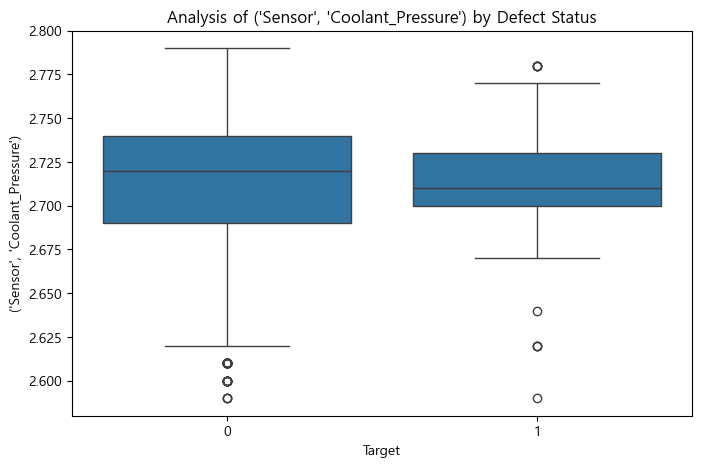

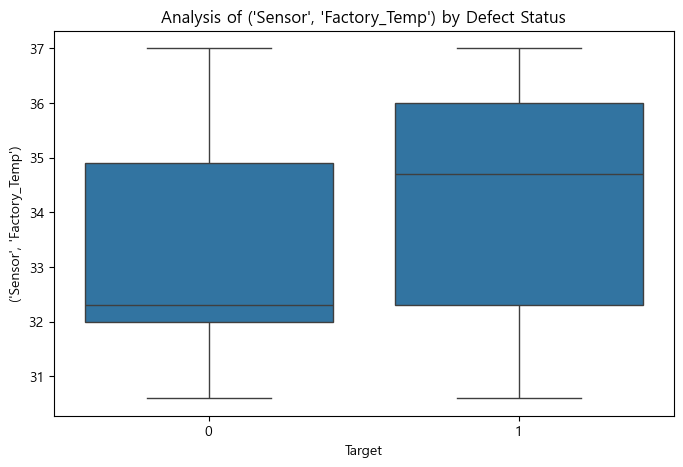

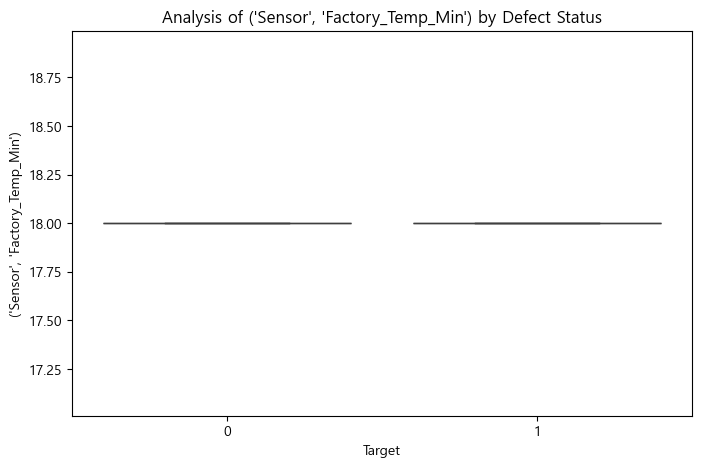

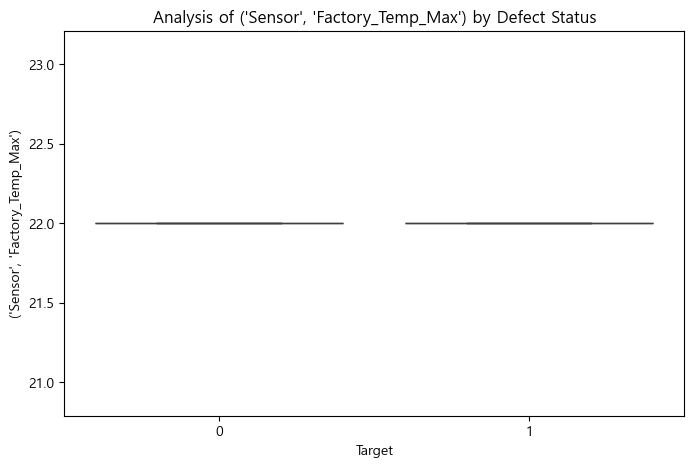

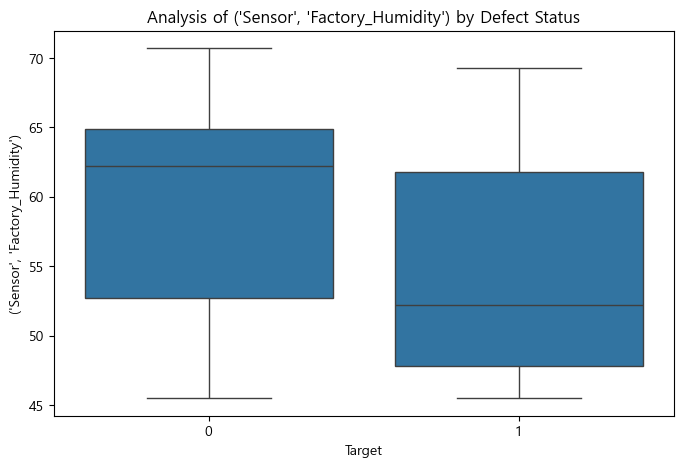

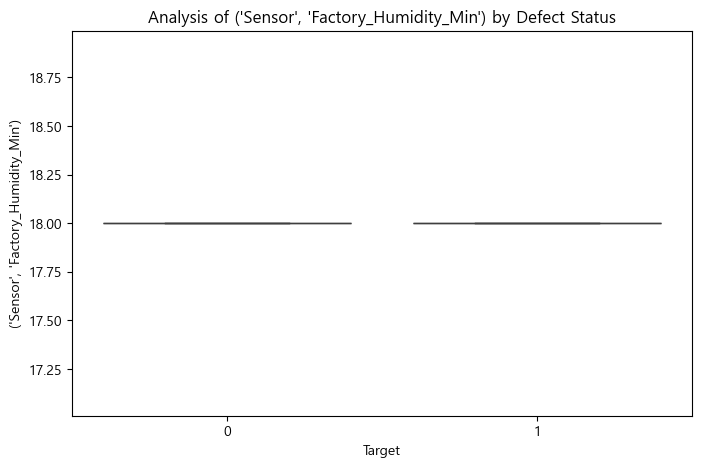

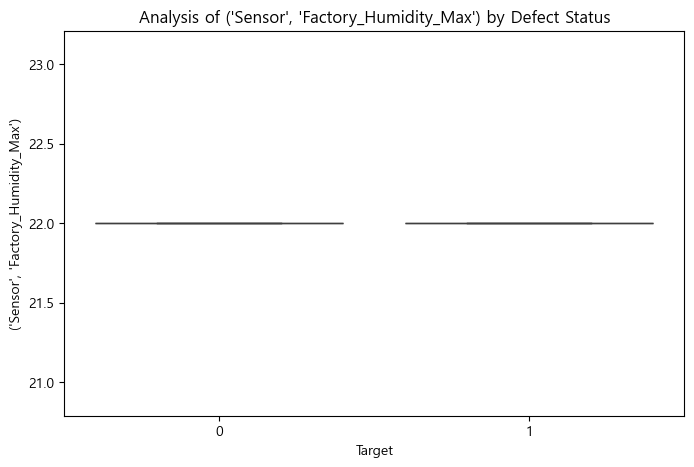

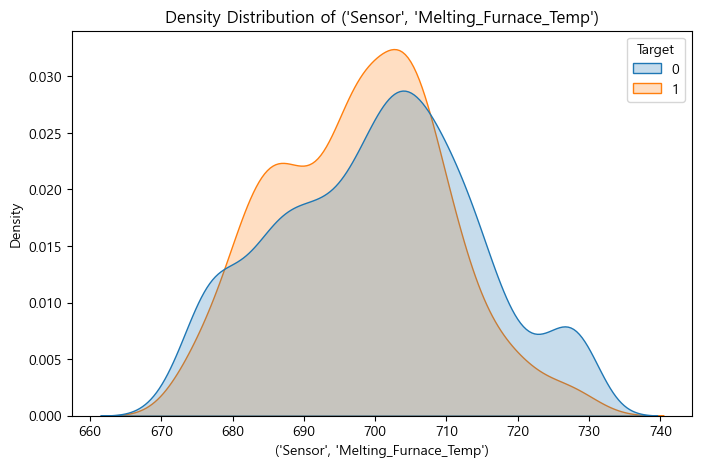

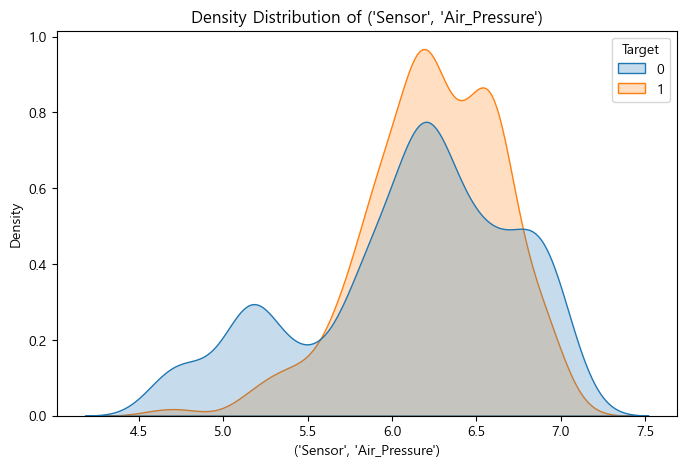

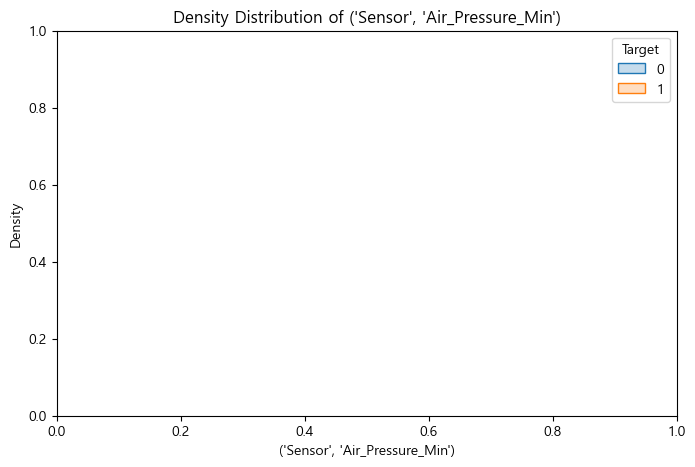

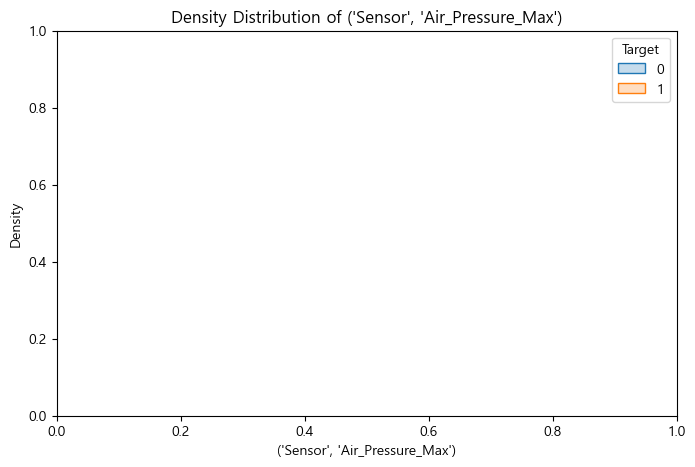

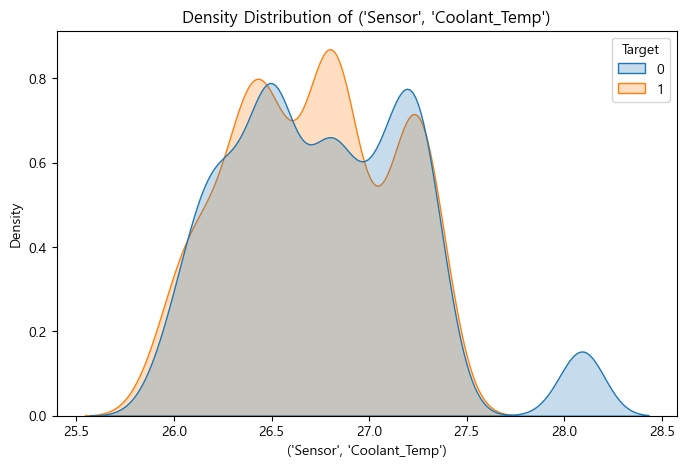

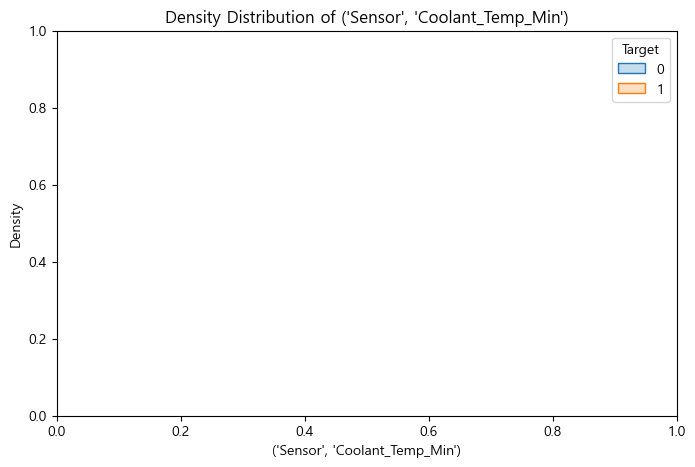

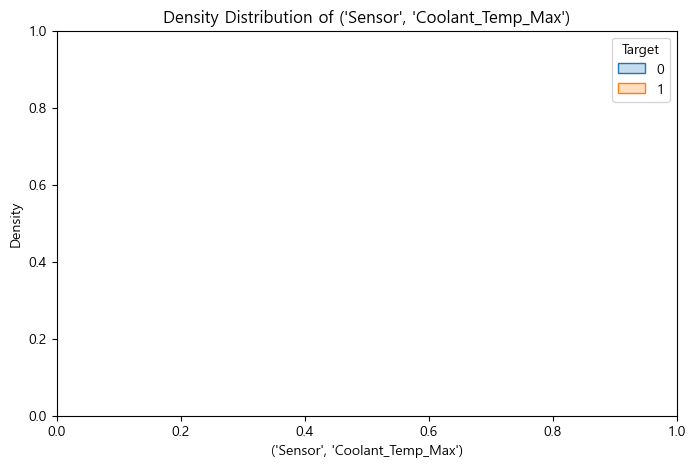

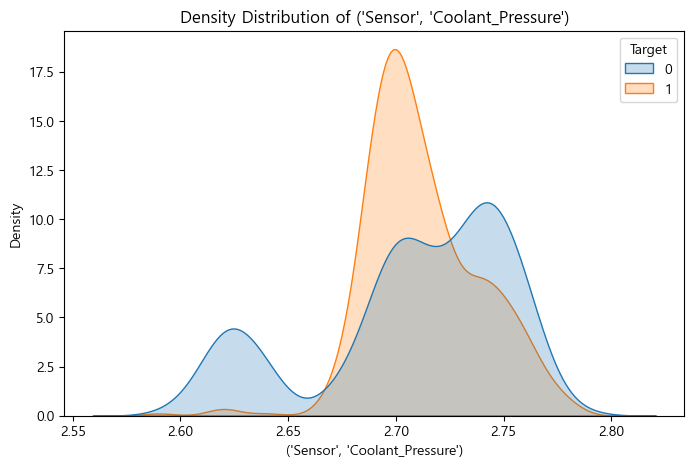

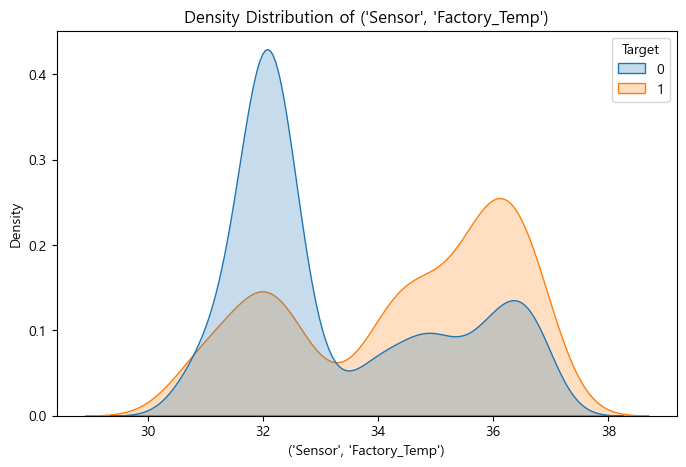

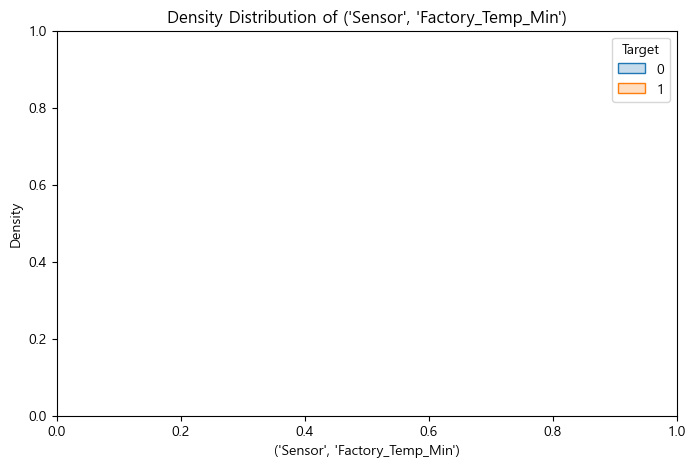

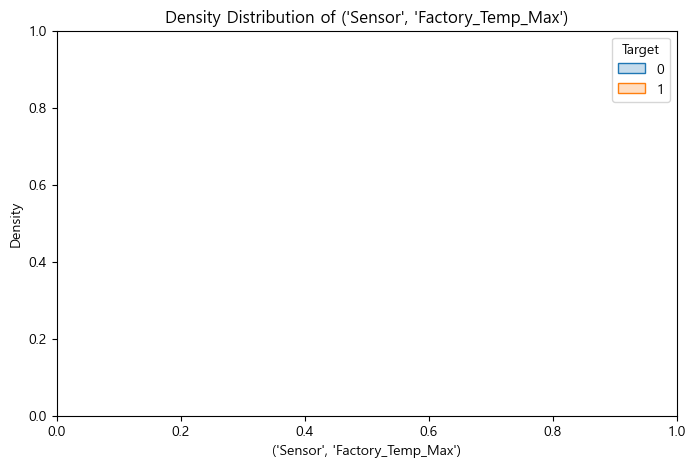

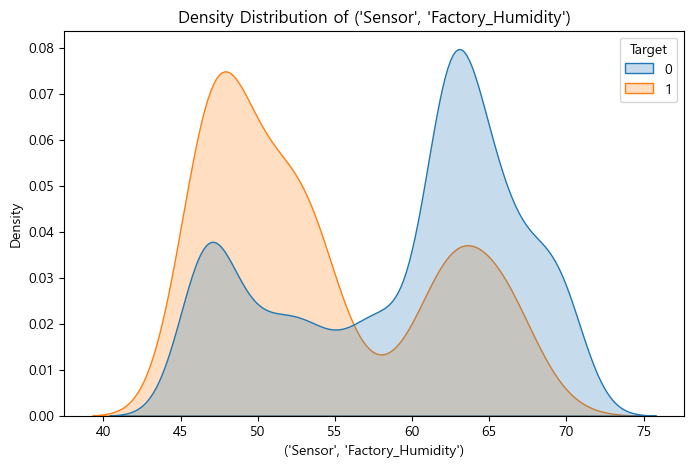

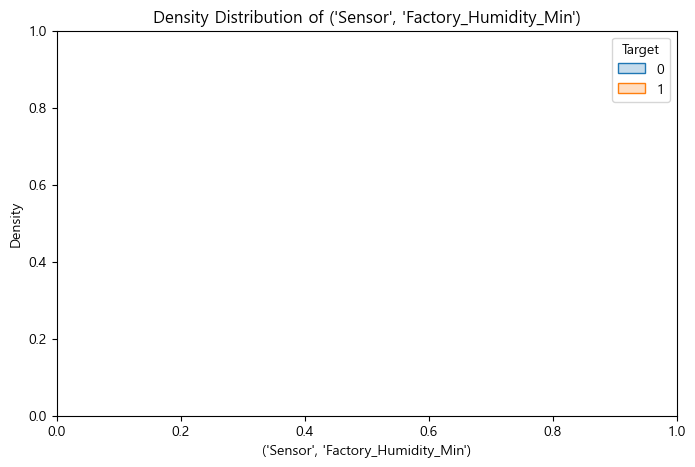

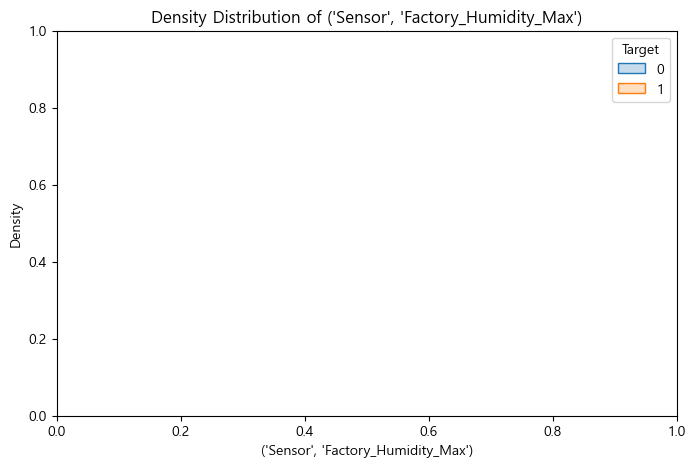

In [19]:
# 'Sensor'가 포함된 모든 컬럼 선택
sensor_cols = [c for c in X_train.columns if 'Sensor' in str(c)]

# 센서별 분포 차이 시각화 (Boxplot)
for col in sensor_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Target', y=col, data=df_eda)
    plt.title(f'Analysis of {col} by Defect Status')
    plt.show()

# 센서별 밀도 차이 시각화 (KDE Plot)
for col in sensor_cols:
    plt.figure(figsize=(8, 5))
    sns.kdeplot(data=df_eda, x=col, hue='Target', fill=True, common_norm=False)
    plt.title(f'Density Distribution of {col}')
    plt.show()